In [56]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_csv(r"D:\Kaggle\delhi_ncr_aqi_dataset.csv")

print(df.shape)

(201664, 25)


In [6]:
df.head()

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201664 entries, 0 to 201663
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   datetime      201664 non-null  object 
 1   date          201664 non-null  object 
 2   year          201664 non-null  int64  
 3   month         201664 non-null  int64  
 4   day           201664 non-null  int64  
 5   hour          201664 non-null  int64  
 6   day_of_week   201664 non-null  object 
 7   is_weekend    201664 non-null  int64  
 8   season        201664 non-null  object 
 9   city          201664 non-null  object 
 10  station       201664 non-null  object 
 11  latitude      201664 non-null  float64
 12  longitude     201664 non-null  float64
 13  pm25          201664 non-null  float64
 14  pm10          201664 non-null  float64
 15  no2           201664 non-null  float64
 16  so2           201664 non-null  float64
 17  co            201664 non-null  float64
 18  o3  

In [4]:
df.describe()

,year,month,day,hour,is_weekend,latitude,longitude,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi
count,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000
mean,2022.499544,6.521898,15.732664,14.750000,0.285584,28.596791,77.208600,183.420341,348.567402,69.761495,16.028998,3.033964,27.185762,26.895227,61.041564,10.528524,5.007801,265.830148
std,1.708185,3.448995,8.801392,6.378691,0.451693,0.112215,0.125113,193.138161,370.016790,75.972086,17.201027,3.284094,13.569802,8.984843,24.737106,6.045043,3.685609,171.508950
min,2020.000000,1.000000,1.000000,6.000000,0.000000,28.372200,77.026600,15.000000,24.000000,8.000000,4.000000,0.300000,12.000000,6.000000,20.000000,2.100000,0.200000,25.000000
25%,2021.000000,4.000000,8.000000,10.500000,0.000000,28.530800,77.071200,55.300000,104.100000,19.900000,4.500000,0.870000,18.000000,19.900000,39.000000,5.900000,1.900000,103.000000
50%,2022.500000,7.000000,16.000000,15.000000,0.000000,28.624600,77.201000,99.500000,189.800000,38.300000,8.700000,1.690000,23.300000,27.600000,58.000000,9.200000,4.400000,232.000000
75%,2024.000000,10.000000,23.000000,19.250000,1.000000,28.668300,77.316400,254.700000,481.200000,94.000000,20.900000,4.120000,31.800000,33.500000,83.000000,14.200000,7.100000,464.000000
max,2025.000000,12.000000,31.000000,23.000000,1.000000,28.776200,77.504000,900.000000,1979.700000,593.500000,121.600000,22.670000,84.000000,44.800000,100.000000,31.500000,15.000000,500.000000


In [7]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day

    df.drop('date', axis=1, inplace=True)

df.head()

,datetime,year,month,day,hour,day_of_week,is_weekend,season,city,station,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020,1,1,6,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020,1,1,12,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020,1,1,18,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020,1,1,23,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020,1,1,6,Wednesday,0,winter,Delhi,"Jahangirpuri, Delhi",...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe


In [8]:
df.isnull().sum().sort_values(ascending=False)

datetime        0
year            0
month           0
day             0
hour            0
day_of_week     0
is_weekend      0
season          0
city            0
station         0
latitude        0
longitude       0
pm25            0
pm10            0
no2             0
so2             0
co              0
o3              0
temperature     0
humidity        0
wind_speed      0
visibility      0
aqi             0
aqi_category    0
dtype: int64

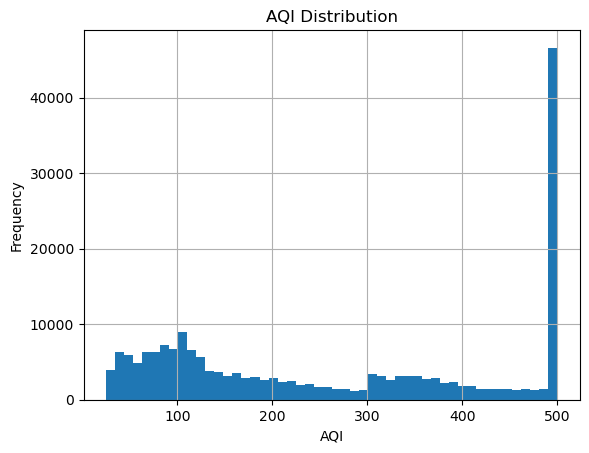

In [11]:
plt.figure()
df['aqi'].hist(bins=50)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

In [12]:
df.skew(numeric_only=True).sort_values(ascending=False)

so2            2.342349
no2            2.254504
co             2.207716
o3             2.077537
pm10           2.047775
pm25           2.001015
wind_speed     0.982238
is_weekend     0.949397
visibility     0.839172
longitude      0.269350
aqi            0.193107
humidity       0.095043
day            0.006505
year          -0.000320
month         -0.008907
hour          -0.091391
temperature   -0.233224
latitude      -0.342474
dtype: float64

In [13]:
corr = df.corr(numeric_only=True)

corr['aqi'].sort_values(ascending=False)

aqi            1.000000
pm25           0.800847
pm10           0.797940
co             0.777170
no2            0.773582
so2            0.755249
month          0.116162
latitude       0.042619
day            0.026363
hour           0.017172
longitude      0.005999
year          -0.022248
is_weekend    -0.038659
humidity      -0.223593
o3            -0.284010
wind_speed    -0.537265
temperature   -0.734334
visibility    -0.857166
Name: aqi, dtype: float64

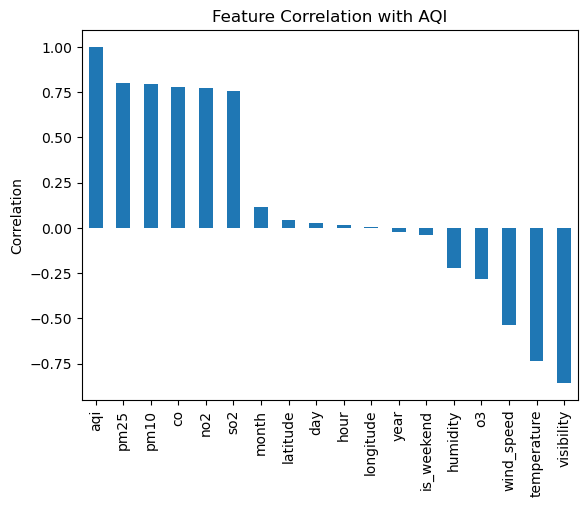

In [22]:
corr = df.corr(numeric_only=True)

aqi_corr = corr['aqi'].sort_values(ascending=False)

plt.figure()
aqi_corr.plot(kind='bar')
plt.title("Feature Correlation with AQI")
plt.ylabel("Correlation")
plt.show()

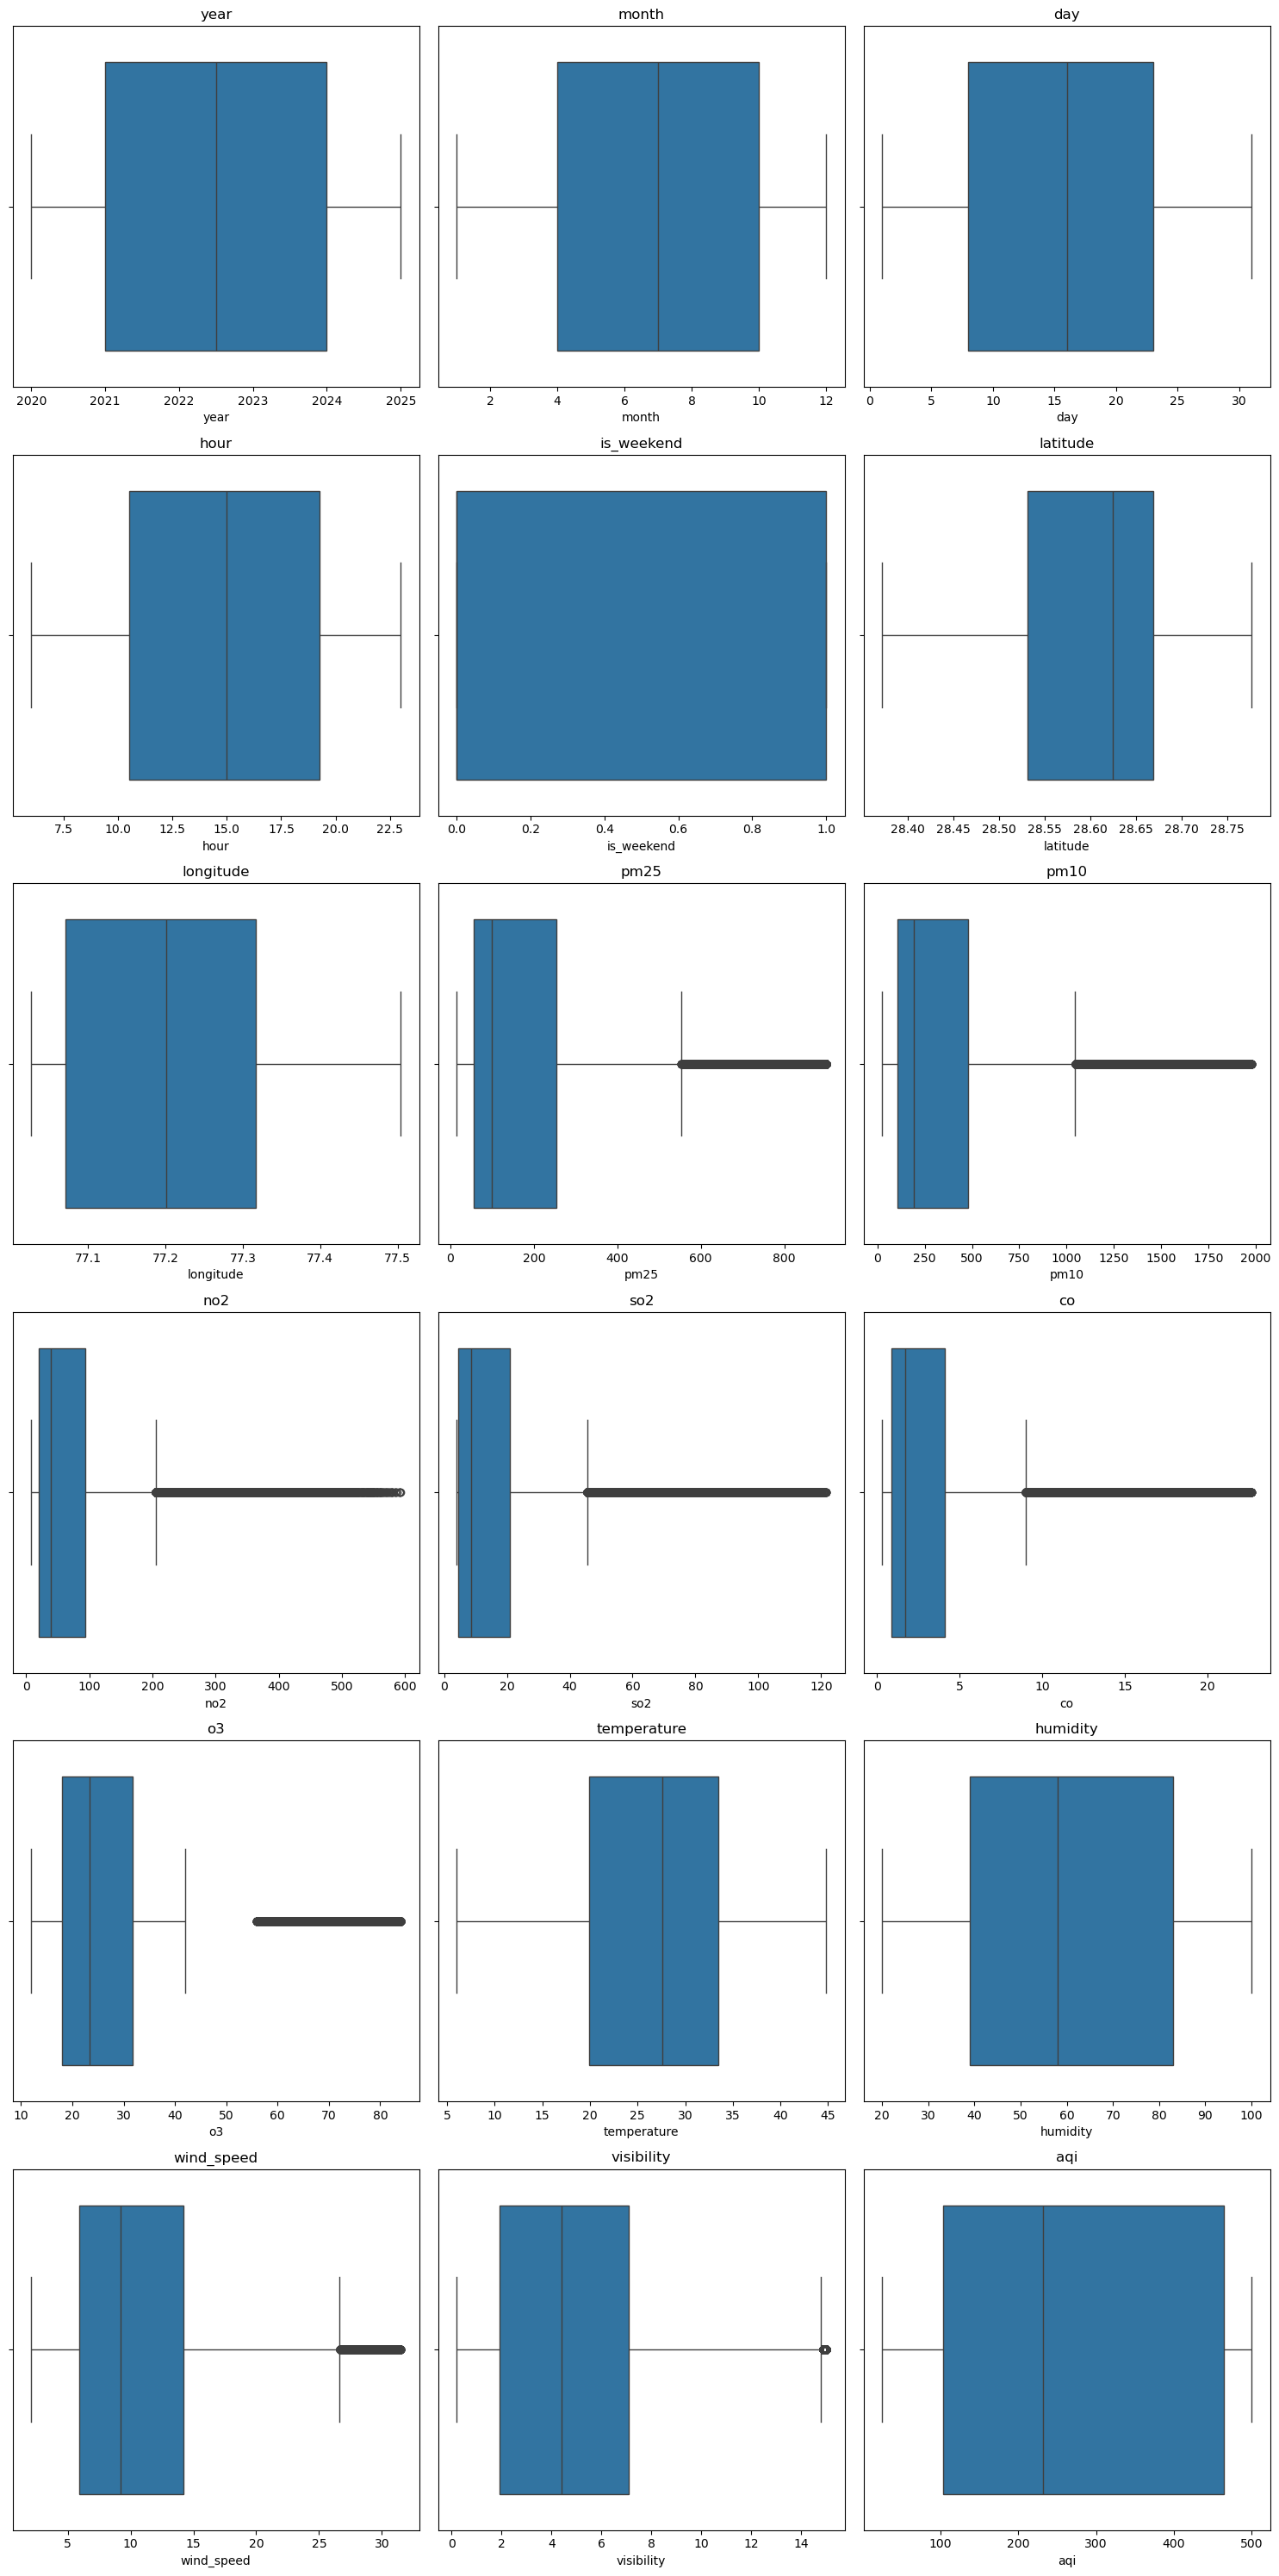

In [23]:
numeric_cols = df.select_dtypes(include='number').columns

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

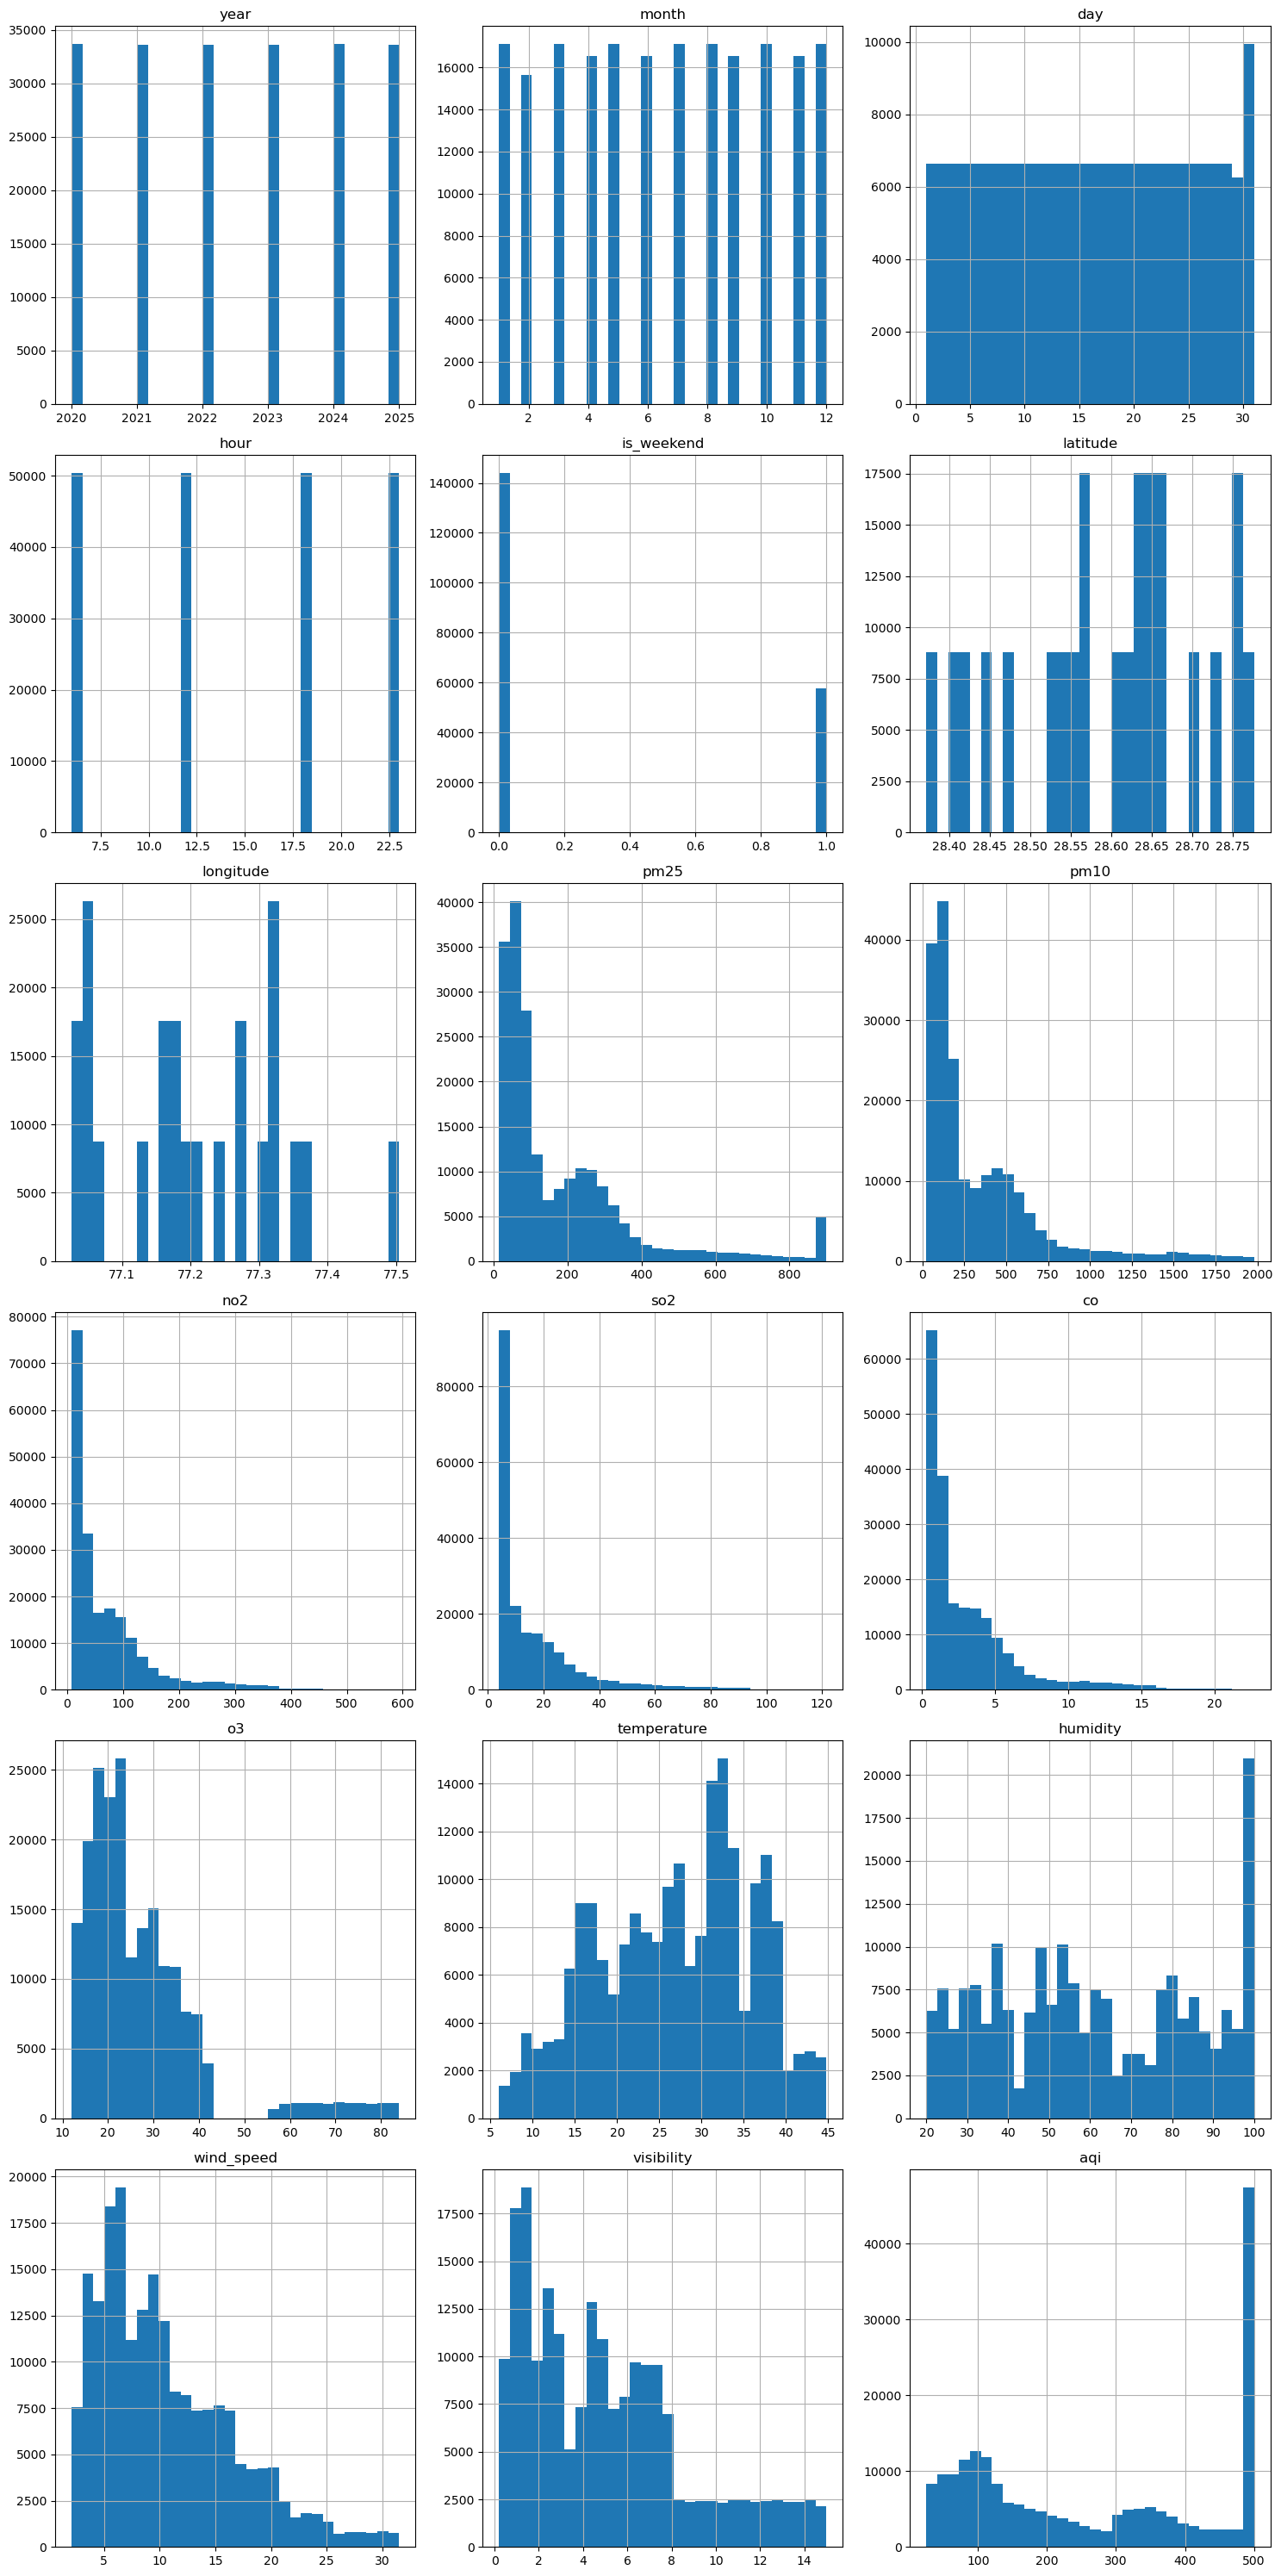

In [24]:
numeric_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    df[col].hist(bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

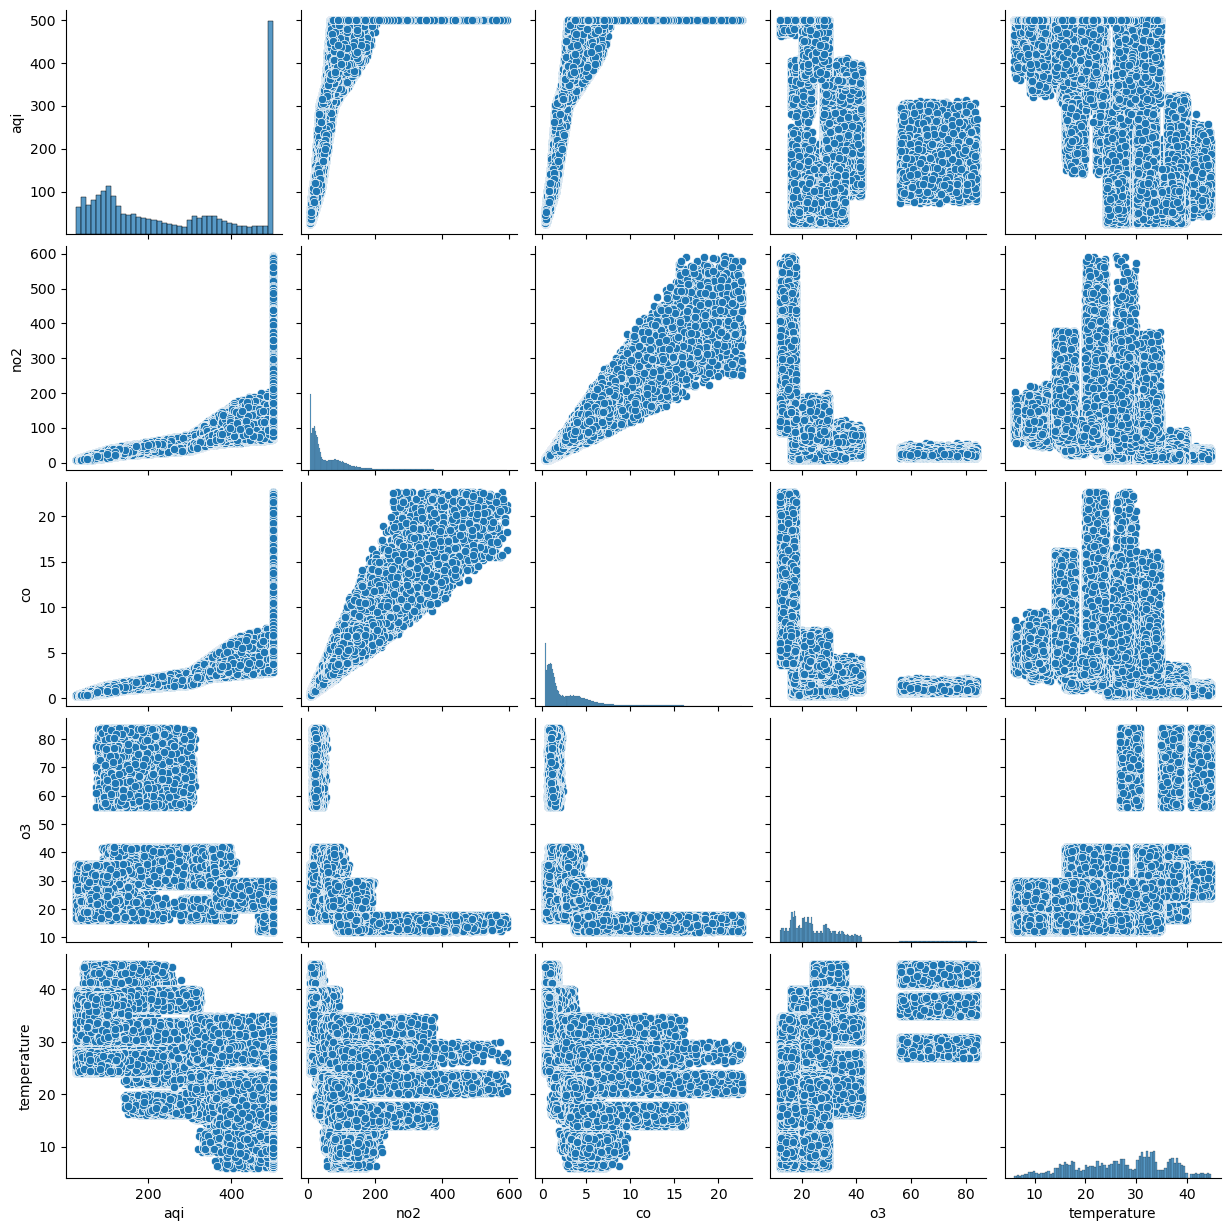

In [19]:
sns.pairplot(df[['aqi', 'no2', 'co', 'o3', 'temperature']].dropna())
plt.show()

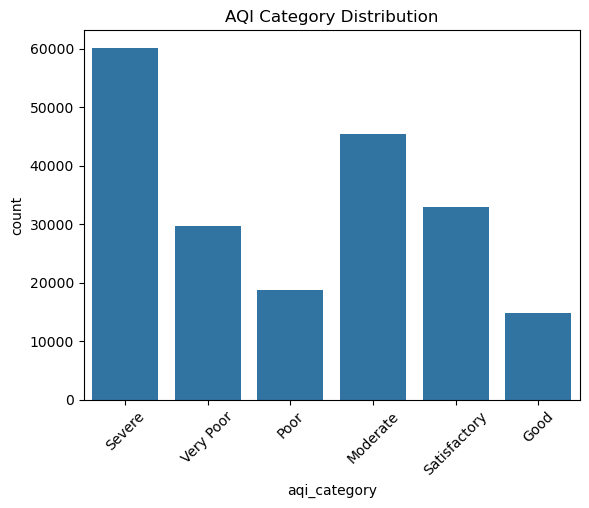

In [29]:
sns.countplot(x=df['aqi_category'])
plt.title("AQI Category Distribution")
plt.xticks(rotation=45)
plt.show()

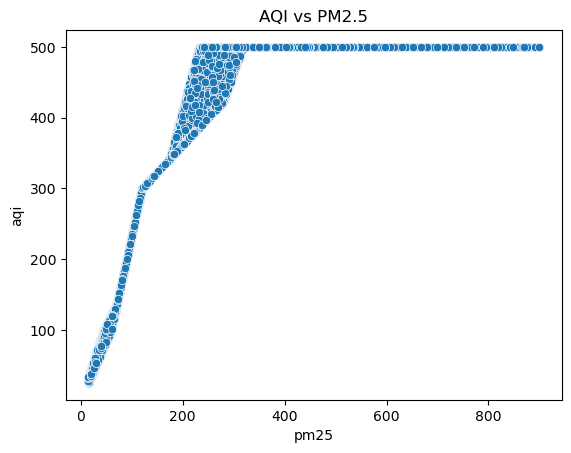

In [30]:
sns.scatterplot(x=df['pm25'], y=df['aqi'])
plt.title("AQI vs PM2.5")
plt.show()

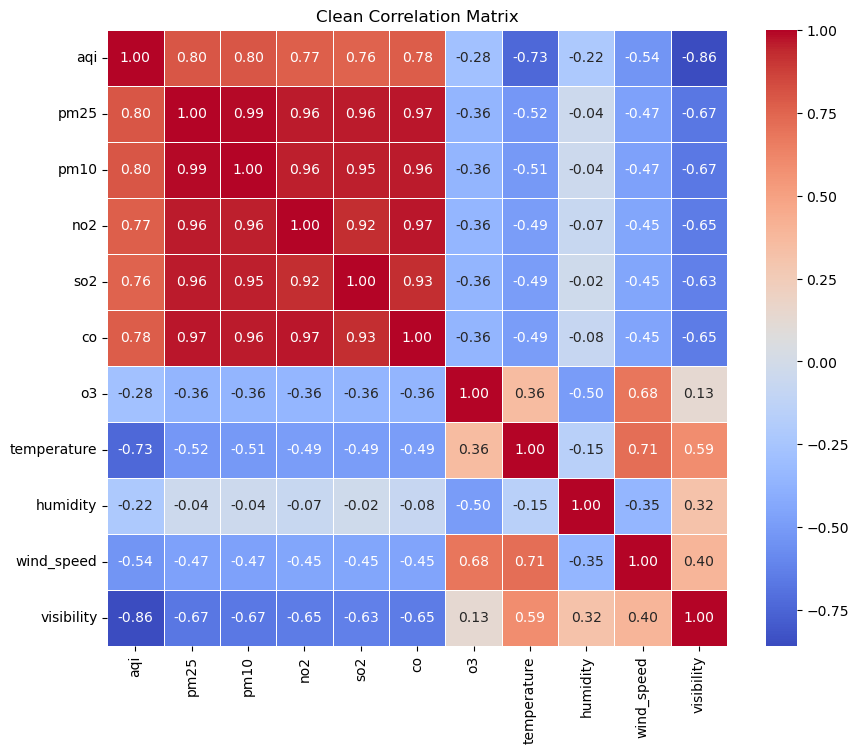

In [27]:
important_cols = [
    'aqi', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
    'temperature', 'humidity', 'wind_speed', 'visibility'
]

corr = df[important_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Clean Correlation Matrix")
plt.show()

In [39]:
# Select only important features
features = [
    'pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
    'temperature', 'humidity', 'wind_speed', 'visibility',
    'month', 'hour'
]

X = df[features]
y = df['aqi']

print("Selected features:", X.columns)

Selected features: Index(['pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'month', 'hour'],
      dtype='object')


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (161331, 12)
Test shape: (40333, 12)


In [42]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [44]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [45]:
y_pred_lr = lr.predict(X_test_scaled)

In [46]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [47]:
y_pred_rf = rf.predict(X_test)

In [48]:
def evaluate(y_true, y_pred, model_name):
    print(f"\n{model_name} Performance:")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))

In [49]:
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression Performance:
MAE: 43.599080473000015
RMSE: 53.86850346455883
R2 Score: 0.9013011141194645

Random Forest Performance:
MAE: 0.002365308804204939
RMSE: 0.032604677333292593
R2 Score: 0.9999999638421796


In [50]:
print(X.columns)

Index(['pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'month', 'hour'],
      dtype='object')


In [51]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())

Total rows: 201664
Duplicate rows: 0


In [52]:
import numpy as np

print("First 10 predictions vs actual:")
for i in range(10):
    print(y_test.iloc[i], "→", y_pred_rf[i])

First 10 predictions vs actual:
117 → 117.0
400 → 399.98
221 → 221.0
284 → 284.0
120 → 120.0
500 → 500.0
500 → 500.0
500 → 500.0
500 → 500.0
196 → 196.0


In [53]:
def aqi_to_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 200:
        return "Poor"
    elif aqi <= 300:
        return "Very Poor"
    else:
        return "Severe"

In [54]:
y_pred_category = [aqi_to_category(x) for x in y_pred_rf]
y_test_category = [aqi_to_category(x) for x in y_test]

In [55]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test_category, y_pred_category))
print(classification_report(y_test_category, y_pred_category))

Accuracy: 0.9998512384399871
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00      2905
    Moderate       1.00      1.00      1.00      6438
        Poor       1.00      1.00      1.00      9083
      Severe       1.00      1.00      1.00     18143
   Very Poor       1.00      1.00      1.00      3764

    accuracy                           1.00     40333
   macro avg       1.00      1.00      1.00     40333
weighted avg       1.00      1.00      1.00     40333



In [57]:
with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)